# AI 모델링 종합실습

**데이터:** Seoul Bike Sharing Demand  
**문제:** 시간별 자전거 대여량 예측  
**구성:** DAY 1 — 데이터 이해·EDA·전처리·Baseline 모델 학습 및 결과 확인


## 실습 운영 안내

- **필수 실습을 우선 수행**합니다.
- 필수 실습을 수업 시간 내 완료한 경우, 같은 단계의 **심화 실습**을 진행합니다.
- 수업 시간 내 완료하지 못한 **심화 실습은 과제로 이어서 수행**합니다.
- DAY 1의 핵심은 코드를 많이 실행하는 것보다 **결과를 확인하고 왜 그런 결과가 나왔는지 설명하는 것**입니다.

## 답안 작성 방법

각 질문을 읽고 바로 아래의 **빈 코드 셀에 직접 코드를 작성**하세요.

- 결과를 확인한 뒤 `답:` 아래에 자신의 해석을 작성합니다.
- 코드가 실행되는 것만으로 끝내지 말고, **그래프·수치가 무엇을 의미하는지 설명**합니다.

## 전체 진행 흐름

### DAY 1
1. 문제 및 데이터 구조 확인
2. 데이터 품질 확인
3. Target 분포 분석
4. Functioning Day 분석
5. 시간대별 대여량 분석
6. 평일·주말·휴일 비교
7. 기온과 대여량 분석
8. 강수·적설과 대여량 분석
9. 계절별 대여량 분석
10. 습도·풍속·일사량·가시거리 분석
11. 수치형 변수 상관관계 분석
12. 전체 컬럼 상관관계 분석
13. 다변량 관계 분석
14. EDA 결과 정리 및 모델링 아이디어 도출
15. 데이터 전처리
16. Train/Test 데이터 분리
17. Data Leakage 확인
18. 회귀 평가지표 확인
19. Baseline 모델 구축
20. Baseline 예측 결과 분석
21. 여러 머신러닝 모델 비교
22. Keras 기반 MLP 회귀
23. PyTorch 기반 MLP 회귀
24. ML/DL 모델 성능 종합 비교

## 0. 환경 설정 및 데이터 불러오기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SeoulBikeData.csv', encoding='cp949')

def canonical_name(col):
    s = str(col).strip().lower()
    if "rented bike count" in s:
        return "rented"
    if s == "hour":
        return "hour"
    if s == "date":
        return "date"
    if s.startswith("temperature"):
        return "temp"
    if s.startswith("humidity"):
        return "humidity"
    if s.startswith("wind speed"):
        return "wind"
    if s.startswith("visibility"):
        return "visibility"
    if s.startswith("dew point"):
        return "dew_point"
    if s.startswith("solar radiation"):
        return "solar"
    if s.startswith("rainfall"):
        return "rainfall"
    if s.startswith("snowfall"):
        return "snowfall"
    if s.startswith("seasons"):
        return "season"
    if s == "holiday":
        return "holiday"
    if s.startswith("functioning day"):
        return "functioning_day"
    return col

df = df.rename(columns={c: canonical_name(c) for c in df.columns})


print(df.head())

         date  rented  hour  temp  humidity  wind  visibility  dew_point  \
0  01/12/2017     254     0  -5.2        37   2.2        2000      -17.6   
1  01/12/2017     204     1  -5.5        38   0.8        2000      -17.6   
2  01/12/2017     173     2  -6.0        39   1.0        2000      -17.7   
3  01/12/2017     107     3  -6.2        40   0.9        2000      -17.6   
4  01/12/2017      78     4  -6.0        36   2.3        2000      -18.6   

   solar  rainfall  snowfall  season     holiday functioning_day  
0    0.0       0.0       0.0  Winter  No Holiday             Yes  
1    0.0       0.0       0.0  Winter  No Holiday             Yes  
2    0.0       0.0       0.0  Winter  No Holiday             Yes  
3    0.0       0.0       0.0  Winter  No Holiday             Yes  
4    0.0       0.0       0.0  Winter  No Holiday             Yes  


# DAY 1 — 데이터 이해 · EDA · 전처리 · Baseline

## STEP 1. 문제 및 데이터 구조

### Q1. [필수] Target과 문제 유형

우리가 예측하려는 값은 무엇이며, Classification / Regression 중 어떤 문제인가?

**답:**  
<br><br>




In [3]:
print(df[["rented"]])

      rented
0        254
1        204
2        173
3        107
4         78
...      ...
8755    1003
8756     764
8757     694
8758     712
8759     584

[8760 rows x 1 columns]


### Q2. [필수] 한 행(Row)의 의미

데이터의 한 행은 무엇을 의미하는가?

**답:**  
<br><br>




In [4]:
df.head()

,date,rented,hour,temp,humidity,wind,visibility,dew_point,solar,rainfall,snowfall,season,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Q3. [필수] 데이터 크기와 변수 유형

행·열의 수는 얼마이며, 수치형/범주형/날짜형 변수는 무엇인가?

**답:**  
<br><br>




In [5]:
print(df.shape)
print(df.info())


(8760, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             8760 non-null   object 
 1   rented           8760 non-null   int64  
 2   hour             8760 non-null   int64  
 3   temp             8760 non-null   float64
 4   humidity         8760 non-null   int64  
 5   wind             8760 non-null   float64
 6   visibility       8760 non-null   int64  
 7   dew_point        8760 non-null   float64
 8   solar            8760 non-null   float64
 9   rainfall         8760 non-null   float64
 10  snowfall         8760 non-null   float64
 11  season           8760 non-null   object 
 12  holiday          8760 non-null   object 
 13  functioning_day  8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.2+ KB
None


## STEP 2. 데이터 품질 확인

### Q4. [필수] 결측치와 중복

결측치나 중복 행이 존재하는가? 결측치가 없다면 전처리가 필요 없는가?

**답:**  
<br><br>




In [6]:
print(df.isna().sum())
print(df.duplicated().sum())

date               0
rented             0
hour               0
temp               0
humidity           0
wind               0
visibility         0
dew_point          0
solar              0
rainfall           0
snowfall           0
season             0
holiday            0
functioning_day    0
dtype: int64
0


### Q5. [필수] 범주형 값 확인

`season`, `holiday`, `functioning_day`에는 어떤 값들이 들어 있는가?

**답:**  
<br><br>




In [7]:
print(df['season'].value_counts())
print()
print(df['holiday'].value_counts())
print()
print(df['functioning_day'].value_counts())
print()

cols = ['season', 'holiday','functioning_day']

for c in cols:
    print(df[c].value_counts())
    print()


Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: season, dtype: int64

No Holiday    8328
Holiday        432
Name: holiday, dtype: int64

Yes    8465
No      295
Name: functioning_day, dtype: int64

Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: season, dtype: int64

No Holiday    8328
Holiday        432
Name: holiday, dtype: int64

Yes    8465
No      295
Name: functioning_day, dtype: int64



## STEP 3. Target 분포 — Histogram / KDE / Boxplot

### Q6. [필수] Target의 분포

`rented`의 평균과 중앙값은 비슷한가? 분포는 대칭적인가?

**답:**  
<br><br>




count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: rented, dtype: float64


,date,rented,hour,temp,humidity,wind,visibility,dew_point,solar,rainfall,snowfall,season,holiday,functioning_day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,01/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


<Axes: xlabel='rented', ylabel='Count'>

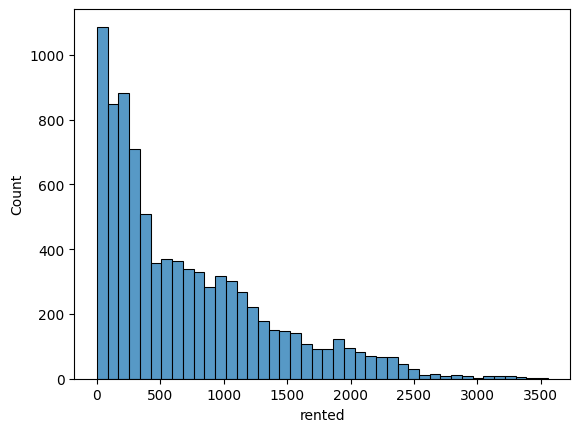

In [8]:
print(df["rented"].describe())

display(df.describe(include='all'))

sns.histplot(data=df, x='rented')

### Q7. [필수] Boxplot과 이상치

Boxplot에서 수염 밖의 값은 모두 삭제해야 하는 이상치인가?

**답:**  
<br><br>




<Axes: xlabel='season', ylabel='rented'>

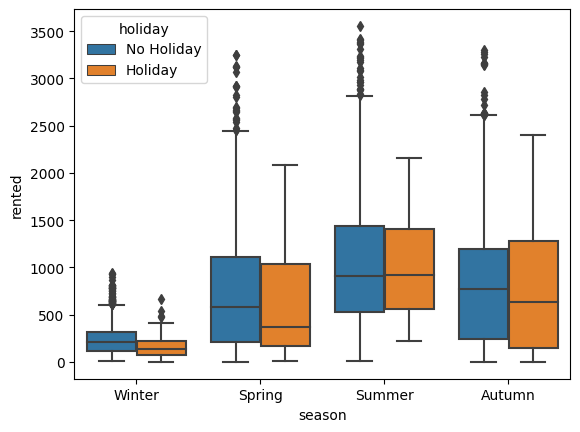

In [9]:
sns.boxplot(data=df, y='rented', x='season', hue='holiday')

## STEP 4. Functioning Day — 0의 의미 확인

### Q8. [필수] 대여량 0의 의미

`rented=0`인 행은 모두 '수요가 없었다'는 뜻인가?

**답:**  
<br><br>




In [10]:
print(df['functioning_day'].value_counts())

df[['functioning_day', 'rented']].value_counts()

print(df[df['rented']==0].describe())
print(df[df['functioning_day']=='No'].describe())

Yes    8465
No      295
Name: functioning_day, dtype: int64
       rented        hour        temp    humidity        wind   visibility  \
count   295.0  295.000000  295.000000  295.000000  295.000000   295.000000   
mean      0.0   11.298305   16.092881   60.494915    1.696949  1521.542373   
std       0.0    6.979501    4.690414   16.331779    1.094120   580.913593   
min       0.0    0.000000    5.200000   21.000000    0.000000   201.000000   
25%       0.0    5.000000   12.300000   49.000000    0.900000  1055.000000   
50%       0.0   11.000000   16.300000   62.000000    1.500000  1814.000000   
75%       0.0   17.000000   19.350000   73.000000    2.350000  2000.000000   
max       0.0   23.000000   26.500000   96.000000    5.300000  2000.000000   

        dew_point       solar    rainfall  snowfall  
count  295.000000  295.000000  295.000000     295.0  
mean     7.770169    0.604780    0.136271       0.0  
std      4.373466    0.883754    1.203795       0.0  
min     -7.000000    

### Q9. [필수] 운영일/비운영일 분포 비교

운영일과 비운영일의 대여량 분포는 어떻게 다른가?

**답:**  
<br><br>




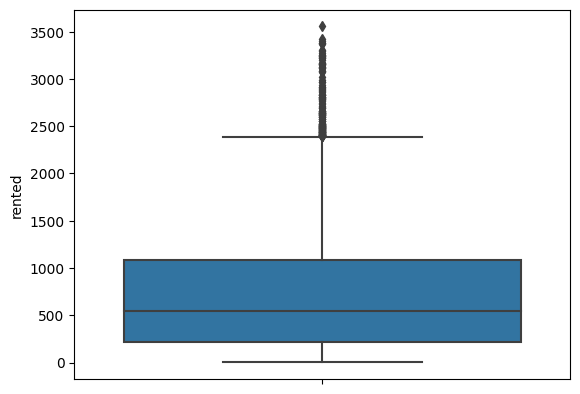

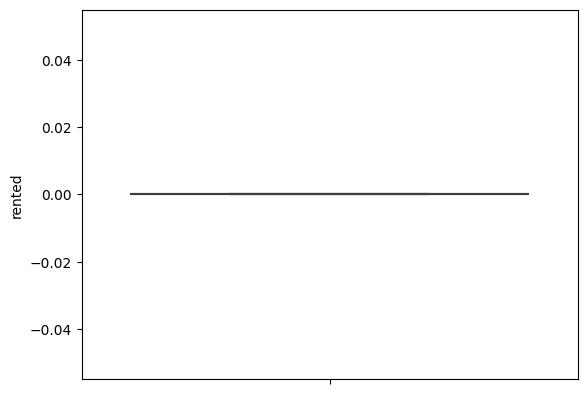

In [11]:
df_open = df[df['functioning_day'] == 'Yes']
df_close = df[df['functioning_day'] == 'No']

sns.boxplot(data=df_open, y='rented')
plt.show()

sns.boxplot(data=df_close, y='rented')
plt.show()

### Q10. [심화] 비운영일 처리 판단

목표가 '운영 중인 날의 수요 예측'이라면 비운영일을 포함해야 할까?

**답:**  
<br><br>




In [12]:
df.groupby("functioning_day")['rented'].agg(['count', 'mean', 'median'])

,count,mean,median
functioning_day,,,
No,295,0.000000,0.0
Yes,8465,729.156999,542.0


## STEP 5. 시간대별 분석 — Line / Boxplot

### Q11. [필수] 시간대별 평균 대여량

출퇴근 시간에 대여량이 증가하는가? 오전과 오후 peak는 같은가?

**답:**  
<br><br>




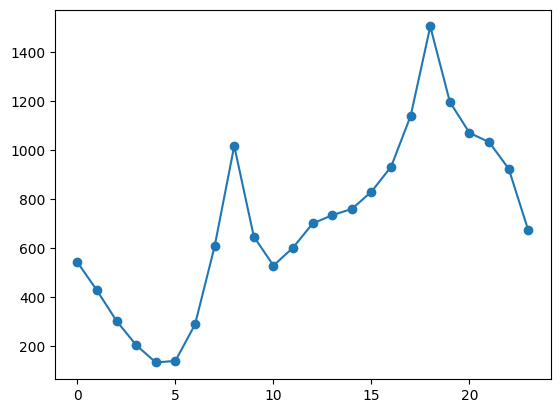

In [13]:
df_hour = df.groupby("hour")['rented'].mean()

plt.plot(df_hour.index,df_hour.values, marker='o')
plt.show()

### Q12. [필수] 시간대별 분포

시간대별 평균값만 보면 충분한가? 시간대에 따라 변동성도 다른가?

**답:**  
<br><br>




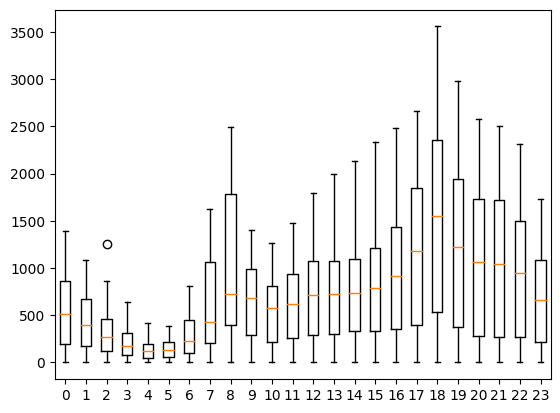

In [14]:
hour_group = [df.loc[df["hour"] == h, "rented"].to_numpy() for h in range(24)]

plt.boxplot(hour_group, labels=range(24))
plt.show()

## STEP 6. 평일 · 주말 · 휴일

In [15]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

df["weekday"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

### Q13. [필수] 평일 vs 주말 시간 패턴

평일과 주말의 시간대별 대여 패턴은 같은가?

**답:**  
<br><br>




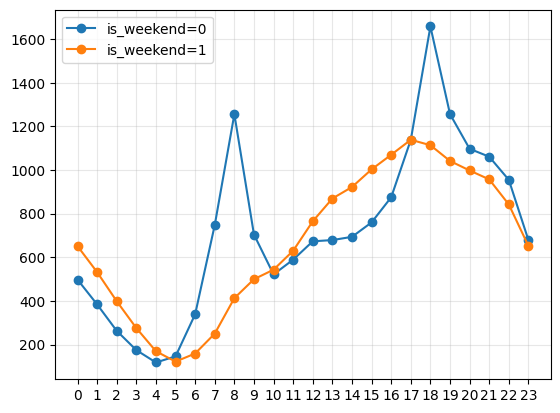

In [16]:
pt = df.pivot_table(index="hour", columns="is_weekend", values="rented", aggfunc="mean")

for col in pt.columns:
    plt.plot(pt.index, pt[col], marker="o", label=f"is_weekend={col}")

plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Q14. [필수] 휴일 여부

휴일과 비휴일의 대여량은 평균뿐 아니라 분포도 다른가?

**답:**  
<br><br>




,count,mean,median,std
holiday,,,,
Holiday,432,499.756944,240.0,570.772769
No Holiday,8328,715.228026,524.5,646.879124


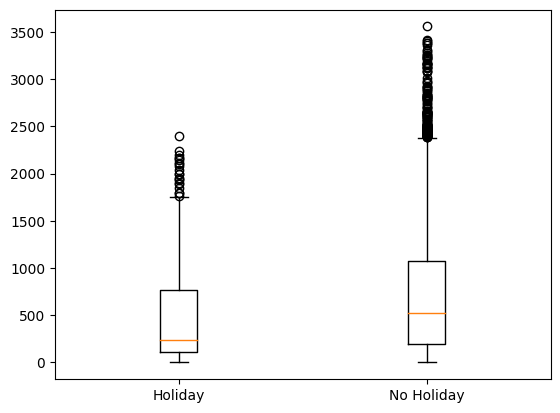

In [17]:
display(df.groupby("holiday")["rented"].agg(['count', 'mean', 'median', 'std']))

groups, labels = [], []
for name, g in df.groupby("holiday"):
    groups.append(g["rented"].to_numpy())
    labels.append(str(name))

plt.boxplot(groups, labels=labels)
plt.show()

### Q15. [심화] 시간 × 주말의 결합 패턴

평일/주말 차이가 특정 시간대에 특히 크게 나타나는가?

**답:**  
<br><br>




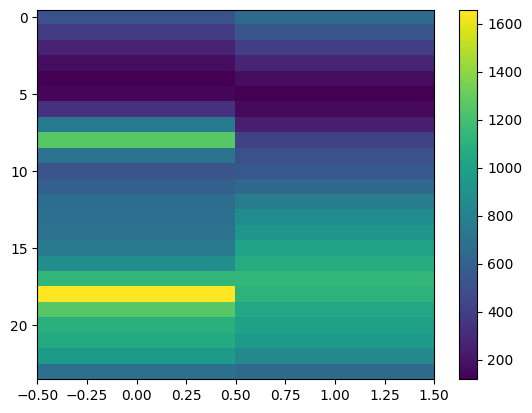

In [18]:
plt.imshow(pt.values, aspect="auto")
plt.colorbar()
plt.show()

## STEP 7. 기온 분석 — Scatter / 구간 비교 / 다변량

### Q16. [필수] 기온과 대여량

기온과 대여량은 어떤 관계를 보이는가? 선형관계라고 볼 수 있는가?

**답:**  
<br><br>




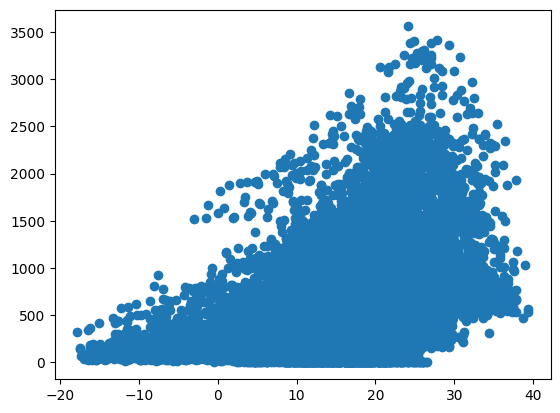

            temp    rented
temp    1.000000  0.538558
rented  0.538558  1.000000


In [19]:
plt.scatter(df["temp"], df["rented"])
plt.show()

print(df[["temp", "rented"]].corr())

### Q17. [필수] 기온 구간

기온을 구간으로 나누면 산점도에서 놓친 패턴이 보이는가?

**답:**  
<br><br>




,count,mean,median
temp_bin,,,
<0,1454,199.521320,170.0
0~10,2143,424.702287,332.0
10~20,2264,765.094081,716.0
20~30,2387,1119.992878,1058.0
30+,512,1106.400391,903.0


<BarContainer object of 5 artists>

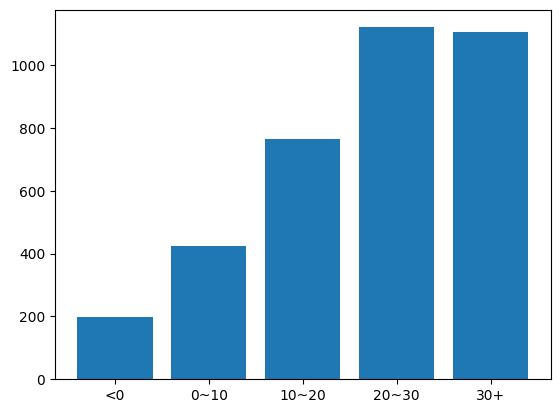

In [20]:
df["temp_bin"] = pd.cut(df["temp"], bins=[-30, 0, 10, 20, 30, 50], labels=["<0", "0~10", "10~20", "20~30", "30+"])

temp_summary = (df.groupby("temp_bin", observed=True)["rented"].agg(['count', 'mean', 'median']))
display(temp_summary)

plt.bar(temp_summary.index.astype(str), temp_summary["mean"])

### Q18. [심화] 기온 × 계절

같은 기온 구간이라도 계절에 따라 대여량이 다른가?

**답:**  
<br><br>




season,Autumn,Spring,Summer,Winter
temp_bin,,,,
<0,608.136364,254.772727,NaN,192.283688
0~10,635.375000,373.589041,NaN,287.754339
10~20,774.891505,774.869015,652.530726,521.000000
20~30,1146.128846,1363.335244,1055.093544,NaN
30+,1678.000000,NaN,1105.281800,NaN


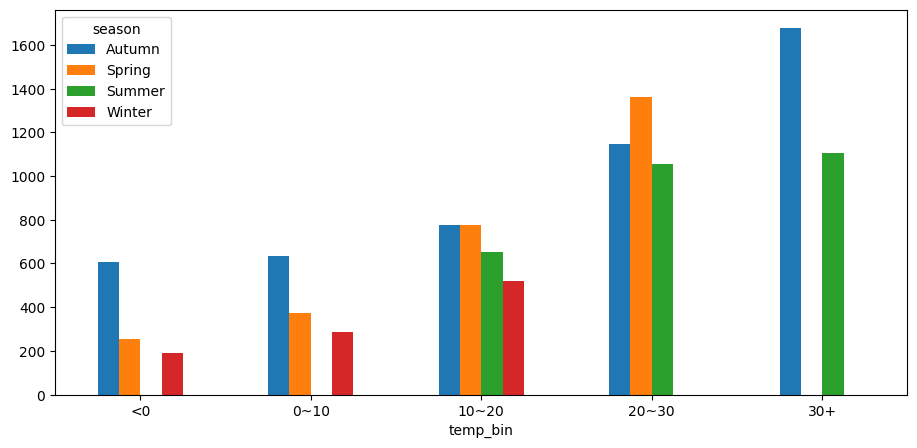

In [21]:
temp_season = df.pivot_table(index="temp_bin", columns='season', values='rented', aggfunc="mean", observed=True)

display(temp_season)

# plt.figure(figsize=(20, 20))

temp_season.plot(kind="bar", figsize=(11,5))
plt.xticks(rotation=0)
plt.show()

## STEP 8. 비 · 눈 — Group comparison / Scatter / Interaction

In [22]:
df["is_rain"] = (df["rainfall"] > 0).astype(int)
df["is_snow"] = (df["snowfall"] > 0).astype(int)

### Q19. [필수] 비가 오는 날

비가 오는 날과 오지 않는 날의 대여량 분포는 어떻게 다른가?

**답:**  
<br><br>




,count,mean,median,std
is_rain,,,,
0,8232,739.311103,562.0,646.777699
1,528,163.456439,67.0,262.070920


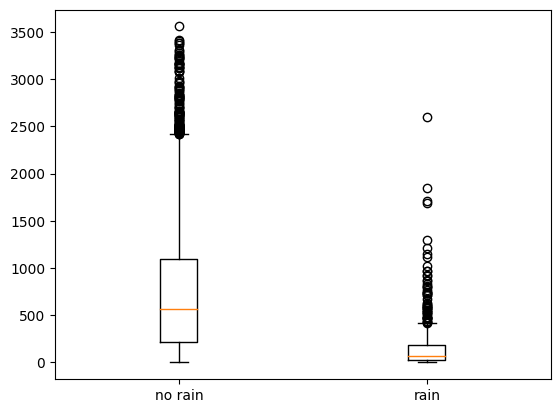

In [23]:
display(df.groupby("is_rain")["rented"].agg(["count", "mean", "median", "std"]))

groups = [df.loc[df["is_rain"] == 0, "rented"].to_numpy(),
          df.loc[df["is_rain"] == 1, "rented"].to_numpy()]

plt.boxplot(groups, labels=["no rain", "rain"])
plt.show()

### Q20. [필수] 강수량의 크기

비가 오는지 여부만 보면 충분한가? 강수량의 크기와 대여량 관계는 어떤가?

**답:**  
<br><br>




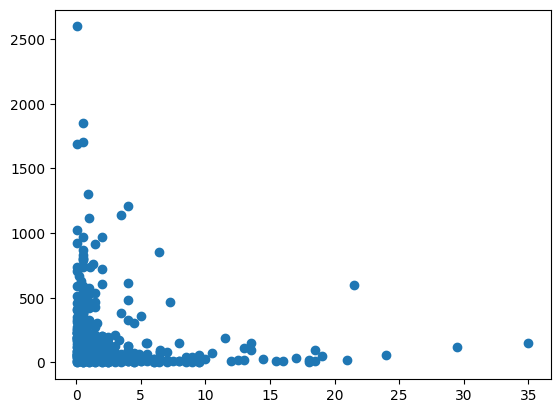

In [24]:
df_rain = df[df["rainfall"] > 0]

plt.scatter(df_rain["rainfall"], df_rain["rented"])

### Q21. [심화] 비의 영향 × 시간대

비의 영향은 모든 시간대에서 동일한가?

**답:**  
<br><br>




is_rain,0,1
hour,,
0,572.218289,140.423077
1,439.982709,160.166667
2,313.804665,111.818182
3,219.746914,73.609756
4,136.852174,59.100000
5,143.758017,66.181818
6,309.880734,95.526316
7,630.661850,157.000000
8,1057.808696,289.350000


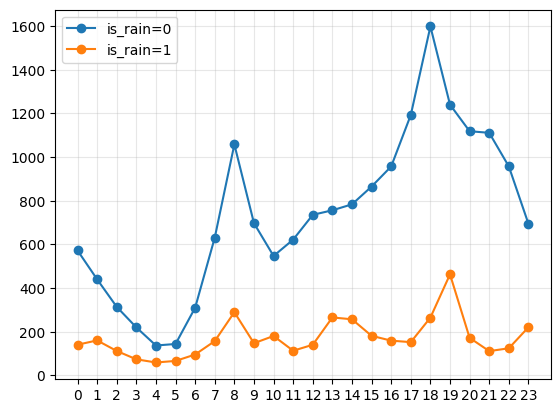

In [25]:
rain_hour = df.pivot_table(index="hour", columns="is_rain", values="rented", aggfunc="mean")
display(rain_hour)

for col in rain_hour.columns:
    plt.plot(rain_hour.index, rain_hour[col], marker="o", label=f"is_rain={col}")

plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Q22. [필수] 눈이 오는 날

눈이 오는 날도 비가 오는 날과 동일한 패턴을 보이는가?

**답:**  
<br><br>




,count,mean,median,std
is_snow,,,,
0,8317,732.272935,557.0,649.355971
1,443,185.101580,149.0,161.006973


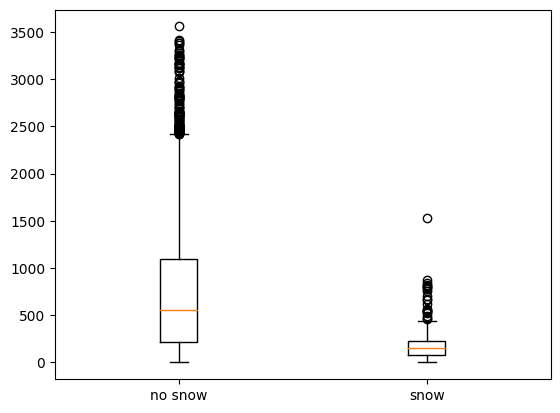

In [26]:
display(df.groupby("is_snow")["rented"].agg(["count", "mean", "median", "std"]))

groups = [df.loc[df["is_snow"] == 0, "rented"].to_numpy(),
          df.loc[df["is_snow"] == 1, "rented"].to_numpy()]

plt.boxplot(groups, labels=["no snow", "snow"])
plt.show()

## STEP 9. 계절 — Boxplot / 시간대 Interaction

### Q23. [필수] 계절별 분포

계절별 평균·중앙값·분산과 대여량 분포는 어떻게 다른가?

**답:**  
<br><br>




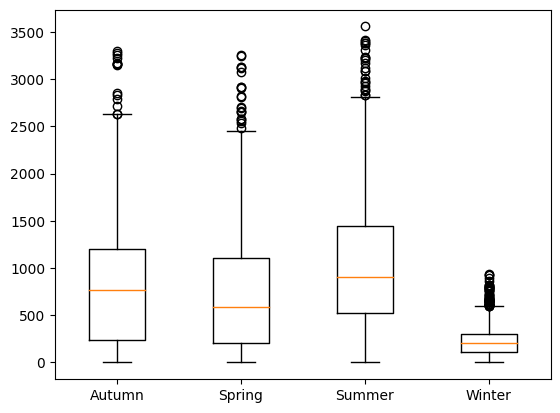

In [27]:
df.groupby('season')['rented'].agg(['count', 'mean', 'median', 'std'])

groups, labels = [], []
for name, g in df.groupby('season'):
    groups.append(g['rented'].to_numpy())
    labels.append(str(name))

plt.boxplot(groups , labels=labels)
plt.show()

### Q24. [심화] 계절 × 시간

모든 계절에서 시간대별 peak가 동일하게 나타나는가?

**답:**  
<br><br>




season,Autumn,Spring,Summer,Winter
hour,,,,
0,623.681319,470.630435,899.065217,165.177778
1,485.714286,356.032609,698.771739,159.055556
2,331.846154,247.467391,505.750000,117.788889
3,225.538462,164.815217,342.673913,77.811111
4,148.593407,105.869565,223.815217,50.477778
5,143.659341,113.652174,245.934783,51.222222
6,316.032967,251.641304,485.836957,92.822222
7,702.186813,601.913043,902.782609,209.566667
8,1197.230769,1013.847826,1418.597826,422.200000


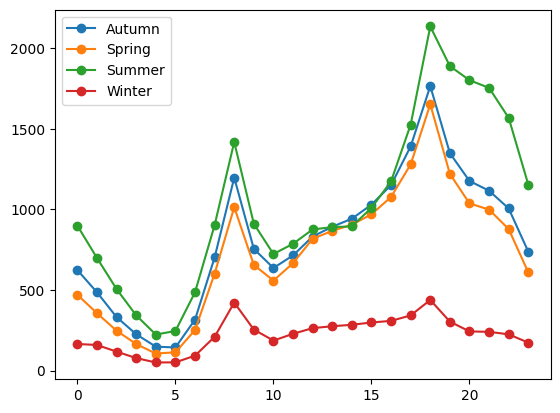

In [28]:
season_hour = df.pivot_table(index="hour", columns = 'season', values = 'rented', aggfunc='mean')
display(season_hour)
 
for col in season_hour.columns:
    plt.plot(season_hour.index, season_hour[col], label=str(col), marker='o' )

plt.legend()
plt.show()

## STEP 10. 습도 · 풍속 · 일사량 · 가시거리

### Q25. [필수] 습도

습도와 대여량은 어떤 관계를 보이는가?

**답:**  
<br><br>




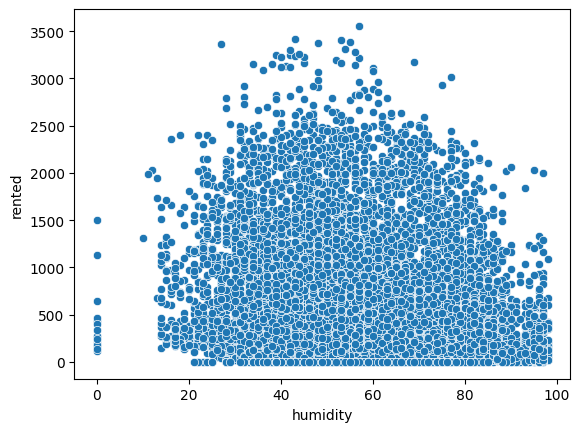

          humidity   rented
humidity   1.00000 -0.19978
rented    -0.19978  1.00000


In [29]:
sns.scatterplot(data=df, x="humidity", y="rented")
plt.show()

print(df[["humidity", "rented"]].corr())


### Q26. [필수] 풍속

풍속과 대여량의 관계는 뚜렷한가? 관계가 약해 보이면 즉시 제거해도 되는가?

**답:**  
<br><br>




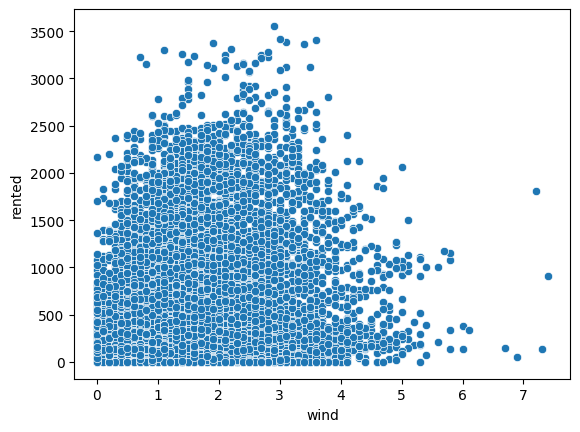

            wind    rented
wind    1.000000  0.121108
rented  0.121108  1.000000


In [30]:
sns.scatterplot(data=df, x="wind", y="rented")
plt.show()

print(df[["wind", "rented"]].corr()) 

### Q27. [필수] 일사량

일사량과 대여량의 관계는 어떠한가? `hour`와도 관련되어 있을 가능성이 있는가?

**답:**  
<br><br>




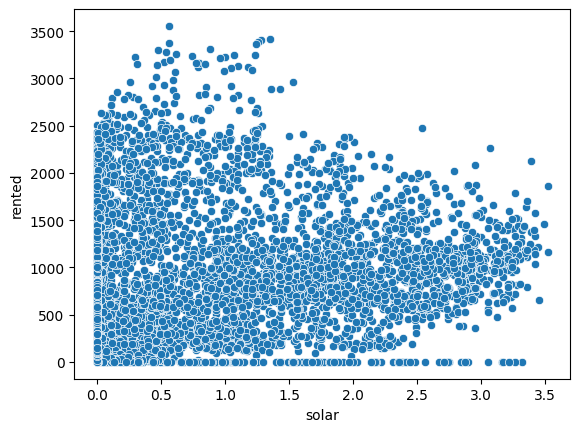

           solar      hour    rented
solar   1.000000  0.145131  0.261837
hour    0.145131  1.000000  0.410257
rented  0.261837  0.410257  1.000000


In [31]:
sns.scatterplot(data=df, x="solar", y="rented")
plt.show()

print(df[["solar","hour", "rented"]].corr()) 

### Q28. [필수] 가시거리

가시거리와 대여량은 어떤 관계를 보이는가?

**답:**  
<br><br>




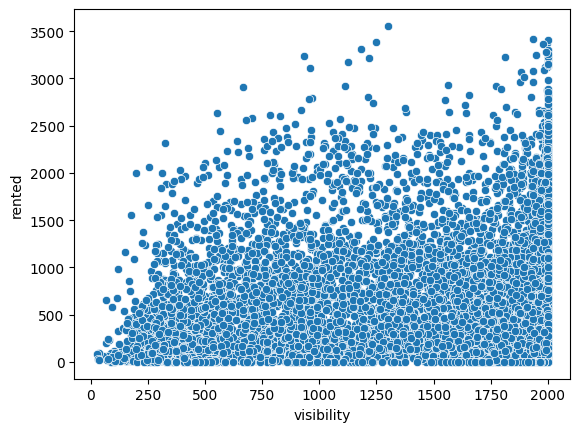

            visibility   rented
visibility     1.00000  0.19928
rented         0.19928  1.00000


In [32]:
sns.scatterplot(data=df, x="visibility", y="rented")
plt.show()

print(df[["visibility","rented"]].corr()) 

## STEP 11. 상관관계 — Correlation Matrix / Heatmap

### Q29. [필수] 상관관계 Heatmap

수치형 Feature 간 상관관계는 어떠하며 Target과 상대적으로 관련이 높은 변수는 무엇인가?

**답:**  
<br><br>




              rented          hour      temp  humidity      wind  visibility  \
rented      1.000000  4.102573e-01  0.538558 -0.199780  0.121108    0.199280   
hour        0.410257  1.000000e+00  0.124114 -0.241644  0.285197    0.098753   
temp        0.538558  1.241145e-01  1.000000  0.159371 -0.036252    0.034794   
humidity   -0.199780 -2.416438e-01  0.159371  1.000000 -0.336683   -0.543090   
wind        0.121108  2.851967e-01 -0.036252 -0.336683  1.000000    0.171507   
visibility  0.199280  9.875348e-02  0.034794 -0.543090  0.171507    1.000000   
dew_point   0.379788  3.054372e-03  0.912798  0.536894 -0.176486   -0.176630   
solar       0.261837  1.451309e-01  0.353505 -0.461919  0.332274    0.149738   
rainfall   -0.123074  8.714642e-03  0.050282  0.236397 -0.019674   -0.167629   
snowfall   -0.141804 -2.151645e-02 -0.218405  0.108183 -0.003554   -0.121695   
weekday    -0.029357  8.797335e-18 -0.003368 -0.007620 -0.021438   -0.026191   
month       0.133514  1.749134e-15  0.21

<Axes: >

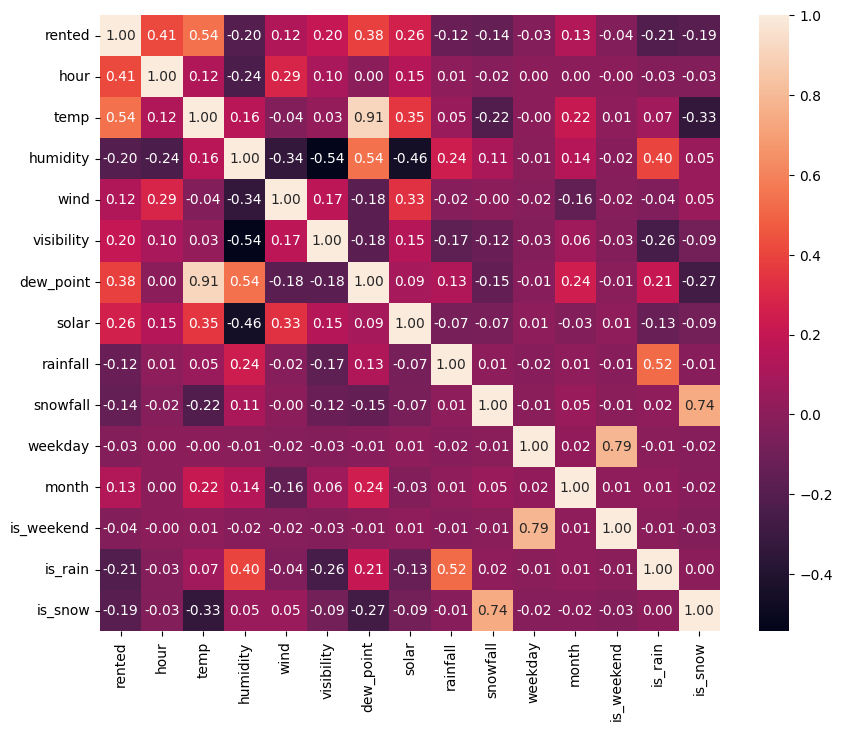

In [38]:
# #1.
# num_cols = df.select_dtypes(include=[int, float])
# print(num_cols.columns)

# 2.
df_corr = df.corr(numeric_only=True)

print(df_corr)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f" )

### Q30. [필수] Target 상관관계 정렬

Target과의 상관계수를 크기순으로 보면 어떤 변수가 상위/하위에 위치하는가?

**답:** temp hour 
<br><br>




In [41]:
df_corr['rented'].sort_values(ascending=False)

rented        1.000000
temp          0.538558
hour          0.410257
dew_point     0.379788
solar         0.261837
visibility    0.199280
month         0.133514
wind          0.121108
weekday      -0.029357
is_weekend   -0.036467
rainfall     -0.123074
snowfall     -0.141804
is_snow      -0.185897
humidity     -0.199780
is_rain      -0.212493
Name: rented, dtype: float64

### Q31. [심화] 높은 Feature 간 상관

Feature끼리 상관관계가 높으면 무조건 하나를 제거해야 하는가?

**답:**  
<br><br>




## STEP 11-1. 전체 컬럼 관점의 상관관계 분석

기존 Heatmap은 **원래 수치형 변수들**의 관계를 보기 위한 것이었다.  
이번에는 범주형 변수도 One-Hot Encoding하고, 날짜에서 만든 변수도 포함하여 **모델에 들어갈 수 있는 거의 모든 컬럼을 숫자로 변환한 뒤 전체 상관관계**를 확인한다.

> 주의: 상관관계는 인과관계가 아니며, One-Hot Encoding된 범주형 변수의 상관계수도 '선형적 동반 변화'를 나타낼 뿐이다.

### Q32. [필수] 전체 컬럼을 상관관계 분석에 그대로 사용할 수 있는가?

문자열 범주형 변수와 날짜형 변수가 포함되어 있을 때 `df.corr()`만 호출하면 모든 컬럼이 분석되는가?

**답:** 에러나옴
<br><br>




In [51]:
df_corr = df.copy()

print(df_corr.columns)
cols = df_corr.columns.tolist()
cols.remove('date')
cols.remove('temp_bin')
print(cols)

df_corr = df_corr[cols]

obj_cols = df_corr.select_dtypes(include="O").columns.tolist()
df_onehot = pd.get_dummies(df_corr, columns=obj_cols, dtype=int)

print(df_onehot.info())


Index(['date', 'rented', 'hour', 'temp', 'humidity', 'wind', 'visibility',
       'dew_point', 'solar', 'rainfall', 'snowfall', 'season', 'holiday',
       'functioning_day', 'weekday', 'day_name', 'month', 'is_weekend',
       'temp_bin', 'is_rain', 'is_snow'],
      dtype='object')
['rented', 'hour', 'temp', 'humidity', 'wind', 'visibility', 'dew_point', 'solar', 'rainfall', 'snowfall', 'season', 'holiday', 'functioning_day', 'weekday', 'day_name', 'month', 'is_weekend', 'is_rain', 'is_snow']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rented               8760 non-null   int64  
 1   hour                 8760 non-null   int64  
 2   temp                 8760 non-null   float64
 3   humidity             8760 non-null   int64  
 4   wind                 8760 non-null   float64
 5   visibility           8760 non-null   i

### Q33. [필수] 전체 컬럼 Heatmap에서 무엇을 확인해야 하는가?

1. `rented`와 상대적으로 상관관계가 큰 변수는 무엇인가?  
2. Feature끼리 매우 높은 양/음의 상관관계를 보이는 조합은 무엇인가?  
3. 날짜 파생변수와 범주형 변수도 Target과 관계가 있는가?

**답:**  
<br><br>




<Axes: >

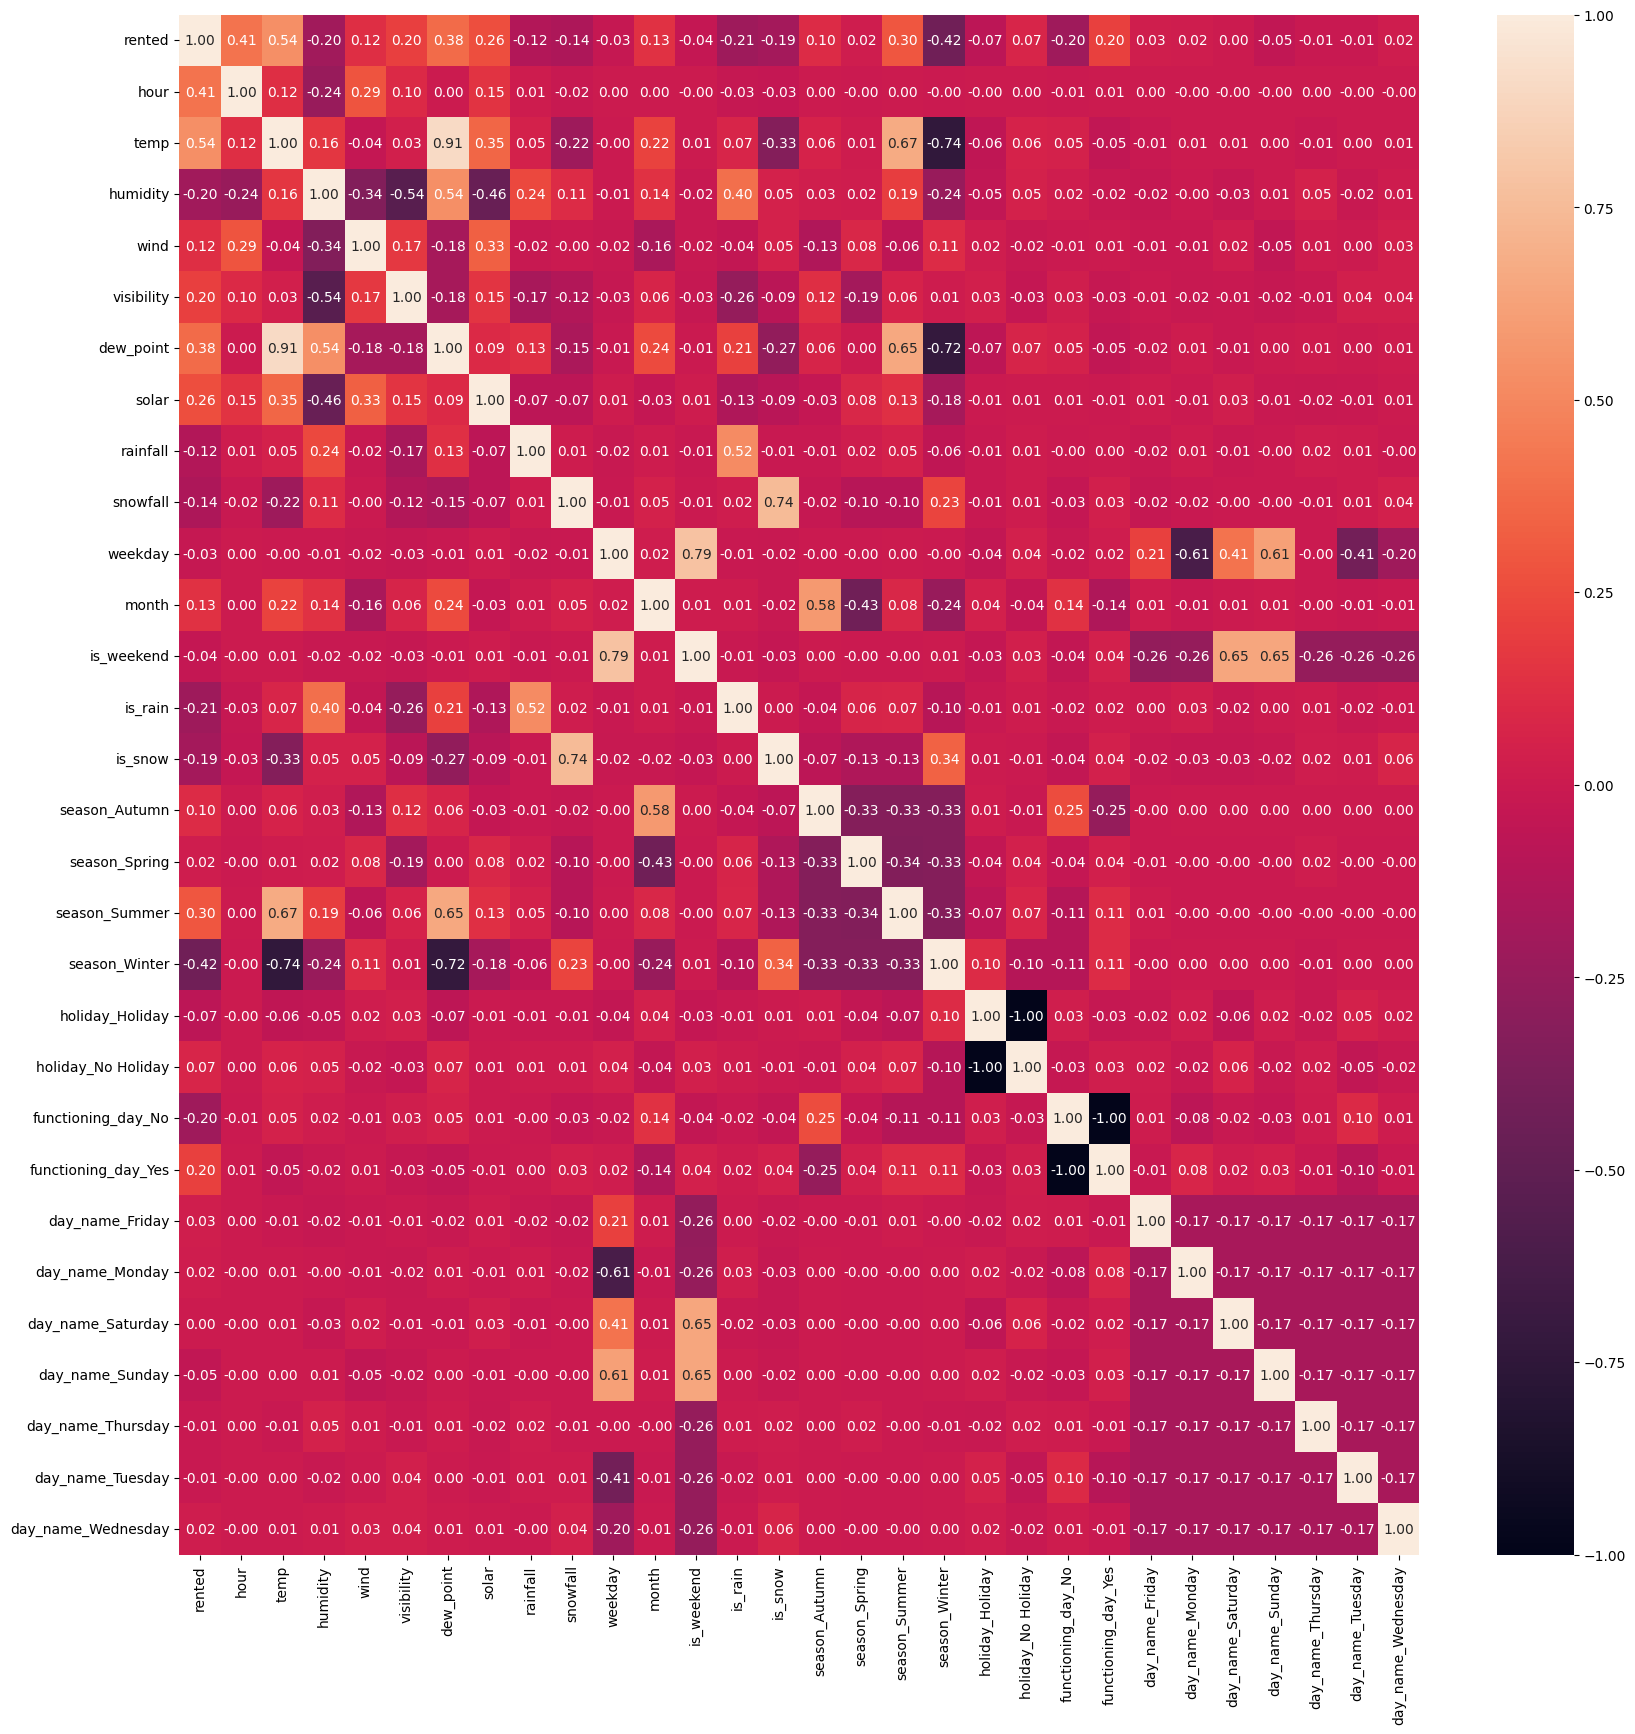

In [55]:
plt.figure(figsize=(20,20))
sns.heatmap(df_onehot.corr(), annot=True, fmt=".2f")

### Q34. [필수] Target과의 상관관계만 따로 정렬하면 어떤 변수가 눈에 띄는가?

**답:**  
<br><br>




In [56]:
df_onehot.corr()['rented'].sort_values(ascending=False)

rented                 1.000000
temp                   0.538558
hour                   0.410257
dew_point              0.379788
season_Summer          0.296549
solar                  0.261837
functioning_day_Yes    0.203943
visibility             0.199280
month                  0.133514
wind                   0.121108
season_Autumn          0.102753
holiday_No Holiday     0.072338
day_name_Friday        0.027169
season_Spring          0.022888
day_name_Wednesday     0.022591
day_name_Monday        0.016407
day_name_Saturday      0.003114
day_name_Thursday     -0.008783
day_name_Tuesday      -0.010506
weekday               -0.029357
is_weekend            -0.036467
day_name_Sunday       -0.050208
holiday_Holiday       -0.072338
rainfall              -0.123074
snowfall              -0.141804
is_snow               -0.185897
humidity              -0.199780
functioning_day_No    -0.203943
is_rain               -0.212493
season_Winter         -0.424925
Name: rented, dtype: float64

### Q35. [심화] Feature끼리 절댓값 기준으로 가장 강한 상관관계를 보이는 조합은 무엇인가?

**답:**  
<br><br>




In [ ]:
corr_pairs = []
df_corr = df_onehot.corr()

for i in range(len(df_onehot.columns)):
    for j in range(i+1, len(df_onehot.columns)):
        col1 = df_onehot.columns[i]
        col2 = df_onehot.columns[j]
        value = df_corr.iloc[i,j]

        corr_pairs.append([col1,col2,value])

corr_pairs = pd.DataFrame(corr_pairs, columns=["col1", "col2", "corr"])

corr_pairs["corr_abs"] = corr_pairs["corr"].abs()

corr_pairs = corr_pairs.sort_values("corr_abs", ascending=False)
print(corr_pairs)

                   col1                 col2          corr      corr_abs
380     holiday_Holiday   holiday_No Holiday -1.000000e+00  1.000000e+00
399  functioning_day_No  functioning_day_Yes -1.000000e+00  1.000000e+00
60                 temp            dew_point  9.127982e-01  9.127982e-01
246             weekday           is_weekend  7.890005e-01  7.890005e-01
229            snowfall              is_snow  7.447918e-01  7.447918e-01
..                  ...                  ...           ...           ...
53                 hour      day_name_Sunday -1.801940e-17  1.801940e-17
56                 hour   day_name_Wednesday -1.471933e-17  1.471933e-17
37                 hour              weekday  8.797335e-18  8.797335e-18
55                 hour     day_name_Tuesday -8.276352e-18  8.276352e-18
52                 hour    day_name_Saturday -6.704892e-18  6.704892e-18

[435 rows x 4 columns]


## STEP 12. 여러 변수 한 번에 보기 — Scatter Matrix / 다변량

### Q36. [필수] Scatter Matrix

여러 수치형 변수의 분포와 쌍별 관계를 한 번에 보면 어떤 패턴이 보이는가?

**답:**  
<br><br>




In [59]:
sns.pairplot(data=df_onehot)

### Q37. [심화] 기온 × 주말 × 대여량

기온과 대여량의 관계가 평일과 주말에서 동일한가?

**답:**  
<br><br>




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


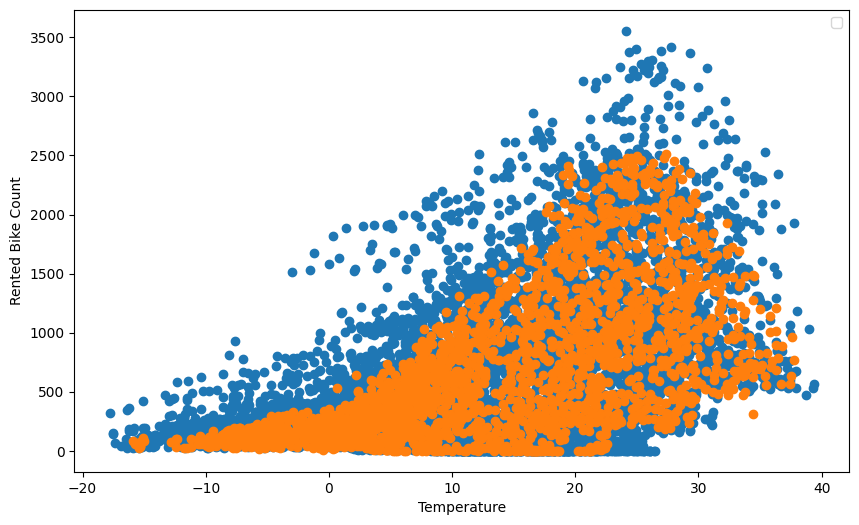

In [62]:
plt.figure(figsize=(10, 6))

for weekend in [0, 1]:
    temp = df[df["is_weekend"] == weekend]
    
    plt.scatter(
        temp["temp"],
        temp["rented"]
    )
plt.xlabel("Temperature")
plt.ylabel("Rented Bike Count")
plt.legend()
plt.show()

### Q38. [심화] 스스로 분석 질문 만들기

지금까지 제시된 질문 외에 데이터로 확인하고 싶은 질문 2개를 만들고 직접 검증하시오.

**답:**  <br>1.습도가 대여량에 미치는 영향은 시간대에 따라 다른가?
          <br>2.일사량이 대여량에 미치는 영향은 계절에 따라 다른가?
<br><br>




1.습도가 대여량에 미치는 영향은 시간대에 따라 다른가?

['Dawn', 'Morning', 'Afternoon', 'Evening']
Categories (4, object): ['Dawn' < 'Morning' < 'Afternoon' < 'Evening']


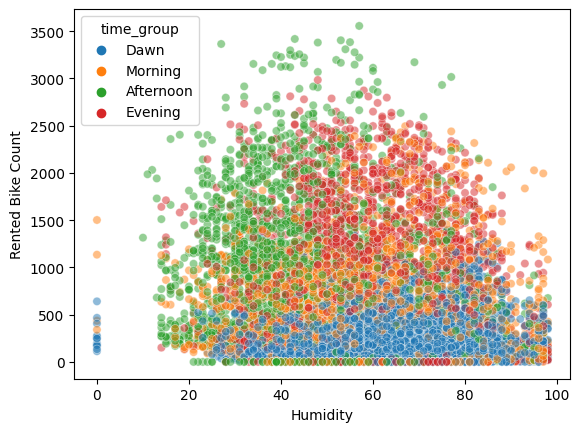

In [86]:
df["time_group"] = pd.cut(
    df["hour"],
    bins=[-1, 6, 12, 18, 23],
    labels=["Dawn", "Morning", "Afternoon", "Evening"]
)

print(df["time_group"].unique())

sns.scatterplot(
    data=df,
    x="humidity",
    y="rented",
    hue="time_group",
    alpha=0.5
)
plt.xlabel("Humidity")
plt.ylabel("Rented Bike Count")
plt.show()

일사량이 대여량에 미치는 영향은 계절에 따라 다른가?

['Winter' 'Spring' 'Summer' 'Autumn']


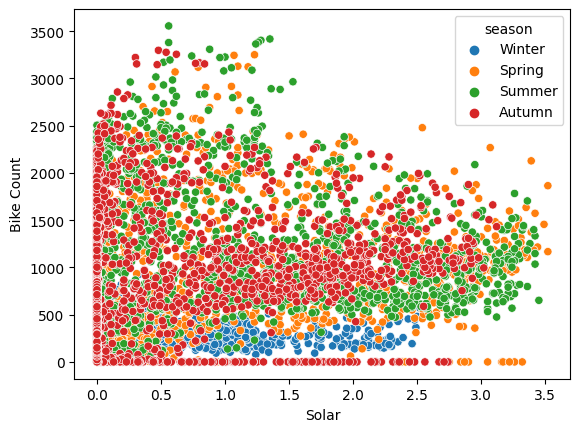

In [87]:
print(df["season"].unique())
sns.scatterplot(
    data=df,
    x="solar",
    y="rented",
    hue="season",
)
plt.xlabel("Solar")
plt.ylabel("Bike Count")
plt.show()

## STEP 13. EDA 결과를 모델링 아이디어로 연결

### Q39. [필수] EDA 결과 요약

    다음 항목을 각각 1~2문장으로 정리하시오.

1) 시간대별 특징: 시간대에 따라 대여량 차이가 나타났으며, 특정 출퇴근 시간대에서 대여량이 증가하는 패턴을 확인했습니다.  
2) 평일/주말 차이: 주말 여부 자체와 대여량의 상관관계는 약했지만, 시간대와 함께 살펴보면 평일과 주말의 대여 패턴에 차이가 나타났습니다.  
3) 기온 영향: 기온이 높아질수록 대여량이 증가하는 경향이 나타났으며, 기온은 대여량과 비교적 높은 양의 상관관계를 보였습니다.  
4) 강수 영향: 비가 오는 경우 대여량이 감소하는 경향을 보였으며, 강수 여부가 대여 수요에 영향을 주는 것으로 나타났습니다.  
5) 계절 영향: 계절별로 대여량 차이가 나타났으며, 여름은 상대적으로 대여량이 높고 겨울은 낮은 경향을 보였습니다.  
6) 예상보다 관계가 약했던 변수: 풍속은 대여량과의 단순 상관관계가 비교적 약하게 나타났습니다.  
7) 추가하고 싶은 Feature 2개와 그 이유: 기온과 습도를 결합한 Feature를 추가하여 날씨의 복합적인 영향을 반영하고, 강수 여부와 시간대를 결합한 Feature를 추가하여 비가 오는 시간대에 따른 대여량 변화를 반영해보고 싶습니다

    **답:**  
    <br><br>

    


# STEP 14. 데이터 전처리

### Q40. [필수] 날짜 Feature

`date` 문자열을 그대로 넣는 대신 어떤 정보를 추출할 수 있는가?

**답:**  
<br><br>




### Q41. [필수] 범주형 Encoding

`season`을 Winter=1, Spring=2, Summer=3, Autumn=4처럼 단순 숫자로 바꾸는 것은 항상 적절한가?

**답:**  
<br><br>




### Q42. [필수] Scaling 필요성

모든 모델에 Scaling이 반드시 필요한가?

**답:**  
<br><br>




### Q43. [심화] Functioning Day 처리 선택

비운영일을 포함한 데이터와 운영일만 남긴 데이터의 크기는 얼마나 다른가?

**답:**  
<br><br>




## STEP 15. Train / Test Split

### Q44. [필수] Random Split

Train/Test를 나누는 이유는 무엇이며, 동일 데이터로 모델 비교 시 Split을 고정하는 이유는?

**답:**  
<br><br>




### Q45. [심화] 시간순 Split

미래 대여량 예측을 실제로 모사한다면 Random Split과 시간순 Split 중 어느 쪽이 더 현실적인가?

**답:**  
<br><br>




## STEP 16. Data Leakage

### Q46. [필수] Scaling Leakage

전체 데이터에 StandardScaler를 먼저 fit한 뒤 Train/Test를 나누면 문제가 있는가?

**답:**  
<br><br>




### Q47. [심화] Target 기반 집계 Leakage

전체 데이터의 '시간대별 평균 대여량'을 Feature로 만든 뒤 Split하면 Leakage가 될 수 있는가?

**답:**  
<br><br>




## STEP 17. 회귀 평가 지표

### Q48. [필수] MAE와 RMSE

MAE와 RMSE 중 큰 오차에 더 민감한 지표는 무엇인가?

**답:**  
<br><br>




### Q49. [필수] R² 해석

`R² = 0.8`은 '정확도 80%'라는 뜻인가? 음수가 될 수도 있는가?

**답:**  
<br><br>




## STEP 18. Baseline — DummyRegressor → Linear Regression

### Q50. [필수] Dummy Baseline

항상 Train 평균만 예측하는 모델도 Baseline으로 의미가 있는가?

**답:**  
<br><br>




### Q51. [필수] Linear Regression Baseline

Linear Regression이 Dummy보다 실제로 개선되는가?

**답:**  
<br><br>




## STEP 19. Baseline 예측 결과 확인

### Q52. [필수] Actual vs Predicted

예측값이 실제값과 비슷하다면 Actual vs Predicted 그래프에서 어떤 모습이 나타나야 하는가?

**답:**  
<br><br>




### Q53. [필수] Residual 분포

Residual(실제값-예측값)은 0 주변에 모이는가? 한쪽으로 치우치는가?

**답:**  
<br><br>




# STEP 20. DAY 1 모델 확장 비교 — 여러 머신러닝 모델

> DAY 1의 목표는 **EDA → 전처리 → Baseline → 여러 ML 모델 → 간단한 DL 모델까지 한 번 완주**하는 것.  
> DAY 2에서는 Feature Engineering과 성능 개선을 더 깊게 진행한다.

### Q54. [필수] 여러 머신러닝 모델 비교

Decision Tree, Random Forest, Gradient Boosting을 같은 Train/Test Split과 같은 평가지표로 비교하시오.

**답:**  
<br><br>




### Q55. [필수] Linear Regression보다 Tree 계열이 좋은가?

Baseline Linear Regression과 Tree/Random Forest/Gradient Boosting의 결과를 비교하고, 차이가 나는 이유를 생각해보시오.

**답:**  
<br><br>




### Q56. [필수] 복잡한 모델이 항상 더 좋은가?

성능이 조금 더 좋은 복잡한 모델을 무조건 선택해야 하는가?

**답:**  
<br><br>




# STEP 21. DAY 1 간단한 딥러닝 — Keras MLP

> 복잡한 딥러닝 구조를 배우는 것이 목적이 아니라, **같은 정형 데이터를 간단한 MLP에 넣어 ML과 성능을 비교**한다.  
> Keras 코드는 `Sequential`만 사용해 최대한 단순하게 구성한다.

### Q57. [필수] Keras MLP 회귀

Dense Layer 2개짜리 간단한 MLP를 학습하고 기존 머신러닝 모델과 성능을 비교하시오.

**답:**  
<br><br>




### Q58. [심화] Keras 학습 곡선

Train loss와 Validation loss의 변화가 비슷한가? 후반에 Validation loss만 증가한다면 무엇을 의미할 수 있는가?

**답:**  
<br><br>




# STEP 22. DAY 1 간단한 딥러닝 — PyTorch MLP

> 별도 `Dataset` 클래스나 복잡한 `DataLoader` 없이 **전체 Tensor를 한 번에 학습**한다.  
> 핵심 흐름: `forward → loss → backward → optimizer.step()`

### Q59. [필수] PyTorch MLP 회귀

Keras와 비슷한 64→32→1 구조를 PyTorch `nn.Sequential`로 구현하고 성능을 비교하시오.

**답:**  
<br><br>




### Q60. [필수] Keras와 PyTorch 결과

비슷한 구조를 사용했는데 Keras와 PyTorch의 결과가 완전히 같지 않아도 되는 이유는?

**답:**  
<br><br>




# STEP 23. DAY 1 전체 모델 성능 비교

### Q61. [필수] ML과 DL 전체 비교

Dummy, Linear Regression, Tree 계열, Keras MLP, PyTorch MLP를 한 번에 비교하시오. 딥러닝이 반드시 가장 좋은가?

**답:**  
<br><br>




### Q62. [필수] DAY 1 모델 선택

DAY 1 결과만 놓고 하나의 모델을 선택한다면 무엇을 선택하겠는가? RMSE 외에 어떤 근거를 함께 볼 것인가?

**답:**  
<br><br>




## DAY 1 완료 기준

- [ ] Target/문제 유형 설명
- [ ] 데이터 품질 확인
- [ ] Histogram/KDE
- [ ] Boxplot
- [ ] 시간대 Line plot
- [ ] 평일/주말·휴일 비교
- [ ] 기온 Scatter + 구간 분석
- [ ] 비/눈 분석
- [ ] 계절 분석
- [ ] 습도·풍속·일사량·가시거리 분석
- [ ] Correlation Heatmap
- [ ] Scatter Matrix 또는 다변량 분석
- [ ] 날짜/범주형/Scaling 개념 확인
- [ ] Random Split 이해
- [ ] Leakage 사례 확인
- [ ] DummyRegressor
- [ ] Linear Regression
- [ ] Decision Tree / Random Forest / Gradient Boosting
- [ ] Keras MLP
- [ ] PyTorch MLP
- [ ] ML / DL 전체 성능 비교
- [ ] Actual vs Predicted / Residual 확인